In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)

# time (monthly)
n_hist = 48
t = np.arange(n_hist)

# true hyperbolic decline (unknown to ML)
qi_true = 1200
di_true = 0.06
b_true  = 0.9

q_true = qi_true / (1 + b_true * di_true * t)**(1 / b_true)

# add noise
q_obs = q_true + np.random.normal(0, 25, size=n_hist)
q_obs = np.clip(q_obs, 10, None)

df = pd.DataFrame({
    "t": t,
    "q_oil": q_obs
})
df["cum_oil"] = df["q_oil"].cumsum()


In [2]:
def make_features(d):
    d = d.copy()
    d["q_lag1"] = d["q_oil"].shift(1)
    d["q_lag2"] = d["q_oil"].shift(2)
    d["q_lag3"] = d["q_oil"].shift(3)
    return d.dropna().reset_index(drop=True)

df_ml = make_features(df)

X = df_ml[["t", "q_lag1", "q_lag2", "q_lag3", "cum_oil"]]
y = df_ml["q_oil"]


In [3]:
from xgboost import XGBRegressor

model = XGBRegressor(
    n_estimators=600,
    learning_rate=0.03,
    max_depth=4,
    subsample=0.9,
    colsample_bytree=0.9,
    objective="reg:squarederror",
    random_state=42
)

model.fit(X, y)


,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,0.9
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_meth

In [4]:
h = 12
future_rates = []

last = df_ml.iloc[-1]
t0 = int(last["t"])

q1 = float(last["q_oil"])
q2 = float(last["q_lag1"])
q3 = float(last["q_lag2"])
cum = float(df["cum_oil"].iloc[-1])

for i in range(1, h + 1):
    X_next = pd.DataFrame([{
        "t": t0 + i,
        "q_lag1": q1,
        "q_lag2": q2,
        "q_lag3": q3,
        "cum_oil": cum
    }])

    q_next = float(model.predict(X_next)[0])
    q_next = max(q_next, 0)

    future_rates.append(q_next)

    # shift
    q3, q2, q1 = q2, q1, q_next
    cum += q_next


In [5]:
from scipy.optimize import curve_fit

def arps(t, qi, di, b):
    return qi / (1 + b * di * t)**(1 / b)

popt, _ = curve_fit(arps, df["t"], df["q_oil"], p0=[1000, 0.05, 0.8])
qi_hat, di_hat, b_hat = popt

t_fore = np.arange(n_hist, n_hist + h)
q_arps = arps(t_fore, qi_hat, di_hat, b_hat)


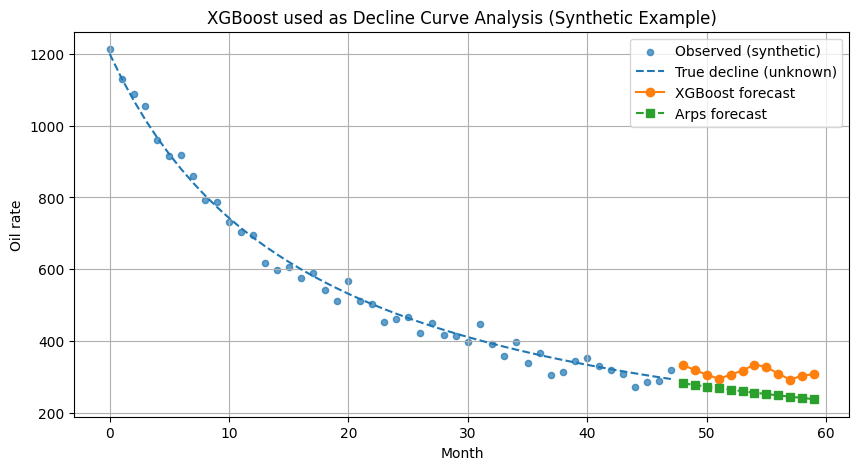

In [6]:
plt.figure(figsize=(10, 5))

plt.scatter(df["t"], df["q_oil"], s=20, label="Observed (synthetic)", alpha=0.7)
plt.plot(df["t"], q_true, "--", label="True decline (unknown)")
plt.plot(t_fore, future_rates, "o-", label="XGBoost forecast")
plt.plot(t_fore, q_arps, "s--", label="Arps forecast")

plt.xlabel("Month")
plt.ylabel("Oil rate")
plt.title("XGBoost used as Decline Curve Analysis (Synthetic Example)")
plt.grid(True)
plt.legend()
plt.show()
